In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/trietes/nyc-borough-geojson/nyc_borough.geojson
/kaggle/input/datasets/trietes/motor-vehicle-collisions-crashes/Motor Vehicle Collisions - Crashes - City of New York.csv


In [51]:
df = pd.read_csv('/kaggle/input/datasets/trietes/motor-vehicle-collisions-crashes/Motor Vehicle Collisions - Crashes - City of New York.csv', low_memory=False)
df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


In [2]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2269187 entries, 0 to 2269186
Data columns (total 42 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   CRASH DATE                     object        
 1   CRASH TIME                     object        
 2   BOROUGH                        object        
 3   ZIP CODE                       object        
 4   LATITUDE                       float64       
 5   LONGITUDE                      float64       
 6   LOCATION                       object        
 7   ON STREET NAME                 object        
 8   CROSS STREET NAME              object        
 9   OFF STREET NAME                object        
 10  NUMBER OF PERSONS INJURED      float64       
 11  NUMBER OF PERSONS KILLED       float64       
 12  NUMBER OF PEDESTRIANS INJURED  int64         
 13  NUMBER OF PEDESTRIANS KILLED   int64         
 14  NUMBER OF CYCLIST INJURED      int64         
 15  NUMBER OF CYCLI

In [53]:
df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

In [54]:
df.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           691375
ZIP CODE                          691661
LATITUDE                          240806
LONGITUDE                         240806
LOCATION                          240806
ON STREET NAME                    499179
CROSS STREET NAME                 870235
OFF STREET NAME                  1862382
NUMBER OF PERSONS INJURED             18
NUMBER OF PERSONS KILLED            8913
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       8202
CONTRIBUTING FACTOR VEHICLE 2     368580
CONTRIBUTING FACTOR VEHICLE 3    2104798
CONTRIBUTING FACTOR VEHICLE 4    2231554
CONTRIBUTING FACTOR VEHICLE 5    2258873
COLLISION_ID                           0
VEHICLE TYPE COD

In [55]:
df.isna().sum()/len(df) #check how much of each column is missing value

CRASH DATE                       0.000000
CRASH TIME                       0.000000
BOROUGH                          0.304680
ZIP CODE                         0.304806
LATITUDE                         0.106120
LONGITUDE                        0.106120
LOCATION                         0.106120
ON STREET NAME                   0.219981
CROSS STREET NAME                0.383501
OFF STREET NAME                  0.820727
NUMBER OF PERSONS INJURED        0.000008
NUMBER OF PERSONS KILLED         0.003928
NUMBER OF PEDESTRIANS INJURED    0.000000
NUMBER OF PEDESTRIANS KILLED     0.000000
NUMBER OF CYCLIST INJURED        0.000000
NUMBER OF CYCLIST KILLED         0.000000
NUMBER OF MOTORIST INJURED       0.000000
NUMBER OF MOTORIST KILLED        0.000000
CONTRIBUTING FACTOR VEHICLE 1    0.003615
CONTRIBUTING FACTOR VEHICLE 2    0.162428
CONTRIBUTING FACTOR VEHICLE 3    0.927556
CONTRIBUTING FACTOR VEHICLE 4    0.983416
CONTRIBUTING FACTOR VEHICLE 5    0.995455
COLLISION_ID                     0

we fill all 18 missing values in NUMBER OF PERSONS INJURED and NUMBER OF PERSONS KILLED with 0, which is the most frequenly appeared value.

In [56]:
type(df)

pandas.core.frame.DataFrame

In [62]:
df['NUMBER OF PERSONS INJURED'] = df['NUMBER OF PERSONS INJURED'].fillna(0)
df['NUMBER OF PERSONS KILLED'] = df['NUMBER OF PERSONS KILLED'].fillna(0)
df['NUMBER OF PERSONS INJURED'].value_counts(dropna=False)
df['NUMBER OF PERSONS KILLED'].value_counts(dropna=False)

NUMBER OF PERSONS KILLED
0.0    2265718
1.0       3356
2.0         91
3.0         15
4.0          4
5.0          2
8.0          1
Name: count, dtype: int64

funnily, borough and zip code has the same missing percentage of 30.4%, but latitude and longitude only miss 10.6%. Let's try to fill in as much missing borough + zip codes as we can using geopandas with NYC Borough shapefile. Also the fact that both shares the same percentage probably means the missing data is not random. let's have a closer look at it. 

In [58]:
missing_boroughs = (df[df['BOROUGH'].isna()][['BOROUGH','ZIP CODE', 'LATITUDE','LONGITUDE', 'ON STREET NAME',
                                              'CROSS STREET NAME','OFF STREET NAME']])
missing_boroughs.head(20)

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME
0,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN
1,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN
3,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN
4,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN
5,NaN,NaN,NaN,NaN,WEST 54 STREET,NaN,NaN
6,NaN,NaN,NaN,NaN,HUTCHINSON RIVER PARKWAY,NaN,NaN
7,NaN,NaN,NaN,NaN,WEST 35 STREET,HENRY HUDSON RIVER,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,61 Ed Koch queensborough bridge
11,NaN,NaN,NaN,NaN,MAJOR DEEGAN EXPRESSWAY RAMP,NaN,NaN
12,NaN,NaN,40.709183,-73.956825,BROOKLYN QUEENS EXPRESSWAY,NaN,NaN


In [59]:
print(missing_boroughs[['LATITUDE', 'LONGITUDE']].notna().all(axis=1).sum()) #how many missing boroughs have valid location?
print(len(missing_boroughs))

488444
691375


In [60]:
missing_boroughs['ON STREET NAME'].value_counts()

ON STREET NAME
BELT PARKWAY                        13399
LONG ISLAND EXPRESSWAY               9777
BROOKLYN QUEENS EXPRESSWAY           9646
GRAND CENTRAL PKWY                   8431
FDR DRIVE                            7264
                                    ...  
Broome Street and                       1
W 244                                   1
CLAVER PLACE                            1
BOULDER STREET                          1
Vandervoort street                      1
Name: count, Length: 15253, dtype: int64

a significant number of missing boroughs have locations to back it up, making filling missing borough values a valid option.

In [13]:
pip show geopandas shapely

Name: geopandas
Version: 1.1.3
Summary: Geographic pandas extensions
Home-page: 
Author: 
Author-email: Kelsey Jordahl <kjordahl@alum.mit.edu>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, packaging, pandas, pyogrio, pyproj, shapely
Required-by: access, bigframes, esda, libpysal, momepy, pointpats, pysal, segregation, spaghetti, splot, spopt, tobler
---
Name: shapely
Version: 2.1.2
Summary: Manipulation and analysis of geometric objects
Home-page: 
Author: Sean Gillies
Author-email: 
License: BSD 3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy
Required-by: bigframes, Cartopy, easyocr, esda, geopandas, libpysal, momepy, pointpats, pysal, rasterstats, spaghetti, spopt
Note: you may need to restart the kernel to use updated packages.


official NYC geospatial borough boundaries:

https://www.nyc.gov/content/planning/pages/resources/datasets/borough-boundaries

In [14]:
import geopandas as gpd

In [15]:
boroughs_gdf = gpd.read_file('/kaggle/input/datasets/trietes/nyc-borough-geojson/nyc_borough.geojson')
print(boroughs_gdf.head())

   OBJECTID  BoroCode       BoroName   Shape__Area  Shape__Length  \
0         1         5  Staten Island  1.623620e+09  325903.403256   
1         2         3       Brooklyn  1.934463e+09  726932.463960   
2         3         4         Queens  3.041420e+09  887873.810812   
3         4         1      Manhattan  6.366314e+08  359535.581244   
4         5         2          Bronx  1.187201e+09  463135.604228   

                                            geometry  
0  MULTIPOLYGON (((-74.05051 40.56643, -74.05047 ...  
1  MULTIPOLYGON (((-73.86328 40.58389, -73.86381 ...  
2  MULTIPOLYGON (((-73.82645 40.59054, -73.82643 ...  
3  MULTIPOLYGON (((-74.01093 40.6845, -74.01193 4...  
4  MULTIPOLYGON (((-73.89681 40.79582, -73.89694 ...  


In [16]:
missing_boroughs_mask = df['BOROUGH'].isna() & df['LATITUDE'].notna() & df['LONGITUDE'].notna()
valid_coords_mask = (df['LATITUDE'] != 0) & (df['LONGITUDE'] != 0)

needs_filling_borough = df[missing_boroughs_mask & valid_coords_mask].copy()
len(needs_filling_borough)

487174

why valid coodination? turns out there is a non-insignificant number of (0,0) location rows, which sounds fine by itself - but is invalid.

In [17]:
df[(df['LATITUDE'] == 0) | (df['LONGITUDE'] == 0)]

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
55,04/24/2022,6:00,QUEENS,11411,0.0,0.0,"(0.0, 0.0)",NaN,NaN,116-44 234 STREET,...,Unspecified,NaN,NaN,NaN,4521460,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
58,04/15/2022,6:11,NaN,NaN,0.0,0.0,"(0.0, 0.0)",EAST 162 STREET,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4522124,Station Wagon/Sport Utility Vehicle,E-Scooter,NaN,NaN,NaN
223,12/09/2021,5:15,NaN,NaN,0.0,0.0,"(0.0, 0.0)",ROCKAWAY BOULEVARD,VANWYCK EXPRESSWAY,NaN,...,Traffic Control Disregarded,NaN,NaN,NaN,4484930,Sedan,Sedan,NaN,NaN,NaN
263,09/11/2021,4:10,MANHATTAN,10033,0.0,0.0,"(0.0, 0.0)",WEST 181 STREET,FORT WASHINGTON AVENUE,NaN,...,NaN,NaN,NaN,NaN,4456191,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN
548,04/15/2021,9:27,NaN,NaN,0.0,0.0,"(0.0, 0.0)",NORWAY AVENUE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4407538,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2267554,07/07/2021,9:12,BROOKLYN,11249,0.0,0.0,"(0.0, 0.0)",WILLIAMSBURG STREET EAST,HEWES STREET,NaN,...,Driver Inattention/Distraction,NaN,NaN,NaN,4435048,Sedan,Sedan,NaN,NaN,NaN
2267705,01/16/2022,3:00,QUEENS,11377,0.0,0.0,"(0.0, 0.0)",WOODSIDE AVENUE,65 STREET,NaN,...,Unspecified,Unspecified,Unspecified,Unspecified,4495176,Taxi,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Sedan,Sedan
2268379,10/25/2021,10:41,NaN,NaN,0.0,0.0,"(0.0, 0.0)",AUDUBON AVENUE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4471110,Sedan,E-Scooter,NaN,NaN,NaN
2268827,07/11/2021,10:15,BROOKLYN,11232,0.0,0.0,"(0.0, 0.0)",8 AVENUE,43 STREET,NaN,...,NaN,NaN,NaN,NaN,4436341,Sedan,NaN,NaN,NaN,NaN


now let's convert the candas DataFrame to a GeoDataFrame. set the CRS (Coordinate Reference System) to EPSG:4326 (Standard WGS84 Lat/Long coordinates)

In [18]:
points_gdf = gpd.GeoDataFrame(
    needs_filling_borough,
    geometry=gpd.points_from_xy(
        needs_filling_borough['LONGITUDE'], needs_filling_borough['LATITUDE']
    ),
    crs='EPSG:4326',
)

In [19]:
boroughs_gdf = boroughs_gdf.to_crs(points_gdf.crs)

In [20]:
joined_gdf = gpd.sjoin(
    points_gdf,
    boroughs_gdf,  # adjust column name if needed (e.g., 'BoroName')
    how='left',
    predicate='within',
)

joined_gdf.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,geometry,index_right,OBJECTID,BoroCode,BoroName,Shape__Area,Shape__Length
12,12/14/2021,17:05,NaN,NaN,40.709183,-73.956825,"(40.709183, -73.956825)",BROOKLYN QUEENS EXPRESSWAY,NaN,NaN,...,NaN,NaN,NaN,POINT (-73.95682 40.70918),1.0,2.0,3.0,Brooklyn,1.934463e+09,726932.463960
16,12/13/2021,0:34,NaN,NaN,40.701275,-73.888870,"(40.701275, -73.88887)",MYRTLE AVENUE,NaN,NaN,...,NaN,NaN,NaN,POINT (-73.88887 40.70128),2.0,3.0,4.0,Queens,3.041420e+09,887873.810812
19,12/14/2021,0:59,NaN,NaN,40.596620,-74.002310,"(40.59662, -74.00231)",BELT PARKWAY,NaN,NaN,...,NaN,NaN,NaN,POINT (-74.00231 40.59662),1.0,2.0,3.0,Brooklyn,1.934463e+09,726932.463960
25,12/14/2021,14:30,NaN,NaN,40.783268,-73.824850,"(40.783268, -73.82485)",WHITESTONE EXPRESSWAY,NaN,NaN,...,Sedan,NaN,NaN,POINT (-73.82485 40.78327),2.0,3.0,4.0,Queens,3.041420e+09,887873.810812
27,12/14/2021,5:46,NaN,NaN,40.744644,-73.770410,"(40.744644, -73.77041)",LONG ISLAND EXPRESSWAY,NaN,NaN,...,NaN,NaN,NaN,POINT (-73.77041 40.74464),2.0,3.0,4.0,Queens,3.041420e+09,887873.810812


In [21]:
recovered_boroughs = joined_gdf['BoroName'].str.upper()
df.loc[recovered_boroughs.index, 'BOROUGH'] = recovered_boroughs
df['BOROUGH'].isna().mean() 
df.head(20)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230,40.621790,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
5,04/26/2023,13:30,NaN,NaN,NaN,NaN,NaN,WEST 54 STREET,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4623759,Sedan,Box Truck,NaN,NaN,NaN
6,11/01/2023,7:12,NaN,NaN,NaN,NaN,NaN,HUTCHINSON RIVER PARKWAY,NaN,NaN,...,Driver Inattention/Distraction,NaN,NaN,NaN,4675709,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
7,11/01/2023,8:01,NaN,NaN,NaN,NaN,NaN,WEST 35 STREET,HENRY HUDSON RIVER,NaN,...,NaN,NaN,NaN,NaN,4675769,Sedan,NaN,NaN,NaN,NaN
8,04/26/2023,22:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61 Ed Koch queensborough bridge,...,NaN,NaN,NaN,NaN,4623865,Sedan,Pick-up Truck,NaN,NaN,NaN
9,09/11/2021,9:35,BROOKLYN,11208,40.667202,-73.866500,"(40.667202, -73.8665)",NaN,NaN,1211 LORING AVENUE,...,NaN,NaN,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN


In [22]:
collisions_by_borough = df['BOROUGH'].value_counts(dropna=True)
collisions_by_borough

BOROUGH
BROOKLYN         630230
QUEENS           583503
MANHATTAN        431245
BRONX            309832
STATEN ISLAND    101269
Name: count, dtype: int64

it doesn't take a genius to see a correlation between number of collisions and population without further analysis. We should find out severity rate of each borough, calculated by total injured/killed divided by total crashes in each borough.

In [29]:
severe_rate_by_year = df.groupby(['BOROUGH','YEAR']).apply(
    lambda x: (x['NUMBER OF PERSONS INJURED'].sum() + x['NUMBER OF PERSONS KILLED'].sum()) / len(x)
    ,include_groups=False
).unstack()
severe_rate_by_year.T

BOROUGH,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
YEAR,,,,,
2012,0.314573,0.323554,0.192060,0.296253,0.260055
2013,0.327695,0.326363,0.189589,0.278616,0.252085
2014,0.305165,0.299197,0.173501,0.252360,0.237800
2015,0.271806,0.270907,0.160758,0.253013,0.243343
2016,0.301796,0.291506,0.184996,0.277036,0.238761
2017,0.299611,0.282847,0.190584,0.275264,0.246188
2018,0.296606,0.299323,0.189485,0.276108,0.234362
2019,0.312654,0.308050,0.212223,0.292307,0.391387
2020,0.403668,0.407021,0.352380,0.390540,0.410414


surprisingly, BRONX have a higher severity rate despite having less collisions than brooklyn. Does this have anything to do with the average speed?

In [30]:
(df.groupby('BOROUGH')[['NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED', 'NUMBER OF MOTORIST INJURED']]
 .sum().apply(lambda x: x / x.sum(), axis=1))

,NUMBER OF PEDESTRIANS INJURED,NUMBER OF CYCLIST INJURED,NUMBER OF MOTORIST INJURED
BOROUGH,,,
BRONX,0.188126,0.058831,0.753043
BROOKLYN,0.193923,0.107864,0.698213
MANHATTAN,0.277791,0.184330,0.537879
QUEENS,0.158764,0.061766,0.779470
STATEN ISLAND,0.142580,0.030130,0.827290


the statistics makes sense since Manhattan is predominantly public transportation while Staten Island, Bronx, and Queens are more car-centric

it's annoying to have ON STREET NAME, CROSS STREET NAME, and OFF STREET NAME, as 3 of these are mutually dependent, so let's focus on ON STREET NAME for now.

In [31]:
df['ON STREET NAME'] = df['ON STREET NAME'].fillna(df['CROSS STREET NAME']).fillna(df['OFF STREET NAME'])

In [32]:
df['ON STREET NAME'].isna().mean()

np.float64(0.04057488430878548)

In [33]:
df[df['ON STREET NAME'] == 'BELT PARKWAY']['BOROUGH'].value_counts(dropna = False)

BOROUGH
BROOKLYN    4468
QUEENS      1954
NaN          535
Name: count, dtype: int64

In [34]:
df['NUMBER OF PERSONS KILLED'].value_counts(dropna = False)

NUMBER OF PERSONS KILLED
0.0    2256805
NaN       8913
1.0       3356
2.0         91
3.0         15
4.0          4
5.0          2
8.0          1
Name: count, dtype: int64

In [35]:
df[df['NUMBER OF PERSONS KILLED'] > 3]

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,DATETIME,YEAR,MONTH,DAY,HOUR,DAY_OF_WEEK,IS_WEEKEND
68777,01/01/2024,5:52,NaN,NaN,NaN,NaN,NaN,CROSS ISLAND PARKWAY,NaN,NaN,...,NaN,NaN,NaN,2024-01-01 05:52:00,2024,1,1,5,0,0
104018,07/04/2024,20:52,MANHATTAN,10002,40.711533,-73.980630,"(40.711533, -73.98063)",WATER STREET,JACKSON STREET,NaN,...,NaN,NaN,NaN,2024-07-04 20:52:00,2024,7,4,20,3,0
225286,01/25/2020,5:35,QUEENS,NaN,40.748398,-73.728790,"(40.748398, -73.72879)",GRAND CENTRAL PKWY,NaN,NaN,...,NaN,NaN,NaN,2020-01-25 05:35:00,2020,1,25,5,5,1
1869628,07/22/2012,3:20,QUEENS,11418,40.697204,-73.813334,"(40.6972045, -73.8133341)",94 AVENUE,VAN WYCK EXPRESSWAY,NaN,...,NaN,NaN,NaN,2012-07-22 03:20:00,2012,7,22,3,6,1
2044918,10/31/2017,15:08,MANHATTAN,10014,40.729046,-74.010730,"(40.729046, -74.01073)",WEST STREET,WEST HOUSTON STREET,NaN,...,Bike,Bike,Bike,2017-10-31 15:08:00,2017,10,31,15,1,0
2081321,09/18/2017,6:17,QUEENS,11354,40.762978,-73.831980,"(40.762978, -73.83198)",NORTHERN BOULEVARD,MAIN STREET,NaN,...,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,2017-09-18 06:17:00,2017,9,18,6,0,0
2117664,04/04/2014,22:35,QUEENS,11105,40.779280,-73.900874,"(40.7792798, -73.9008742)",19 AVENUE,37 STREET,NaN,...,NaN,NaN,NaN,2014-04-04 22:35:00,2014,4,4,22,4,0


crashes with large number of casualties often involves being on big roads, and one vehicle ramming attack.
https://en.wikipedia.org/wiki/2017_New_York_City_truck_attack

let's assume that missing `NUMBER OF PERSONS KILLED` values are all 0, trusting that anyone in charge of filling in data won't forget to add a value in case there are casualties. We fill in missing values with 0:

In [ ]:
#df['NUMBER OF PERSONS KILLED'].fillna(value=0,inplace=True)
df = df.fillna({'NUMBER OF PERSONS KILLED': 0})

In [ ]:
df['NUMBER OF PERSONS KILLED'].value_counts(dropna = False)

In [ ]:
#rows_with_missing = df[[]]].isna().any(axis=1).sum()
#total_rows = len(df)

#### datetime munging

In [61]:
df['DATETIME'] = pd.to_datetime(
    df['CRASH DATE'] + ' ' + df['CRASH TIME'], format='%m/%d/%Y %H:%M'
)

# Extract basic datetime attributes
df['YEAR'] = df['DATETIME'].dt.year
df['MONTH'] = df['DATETIME'].dt.month
df['DAY'] = df['DATETIME'].dt.day
df['HOUR'] = df['DATETIME'].dt.hour
df['DAY_OF_WEEK'] = df['DATETIME'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)

#### visualisation

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
collisions_by_borough.values

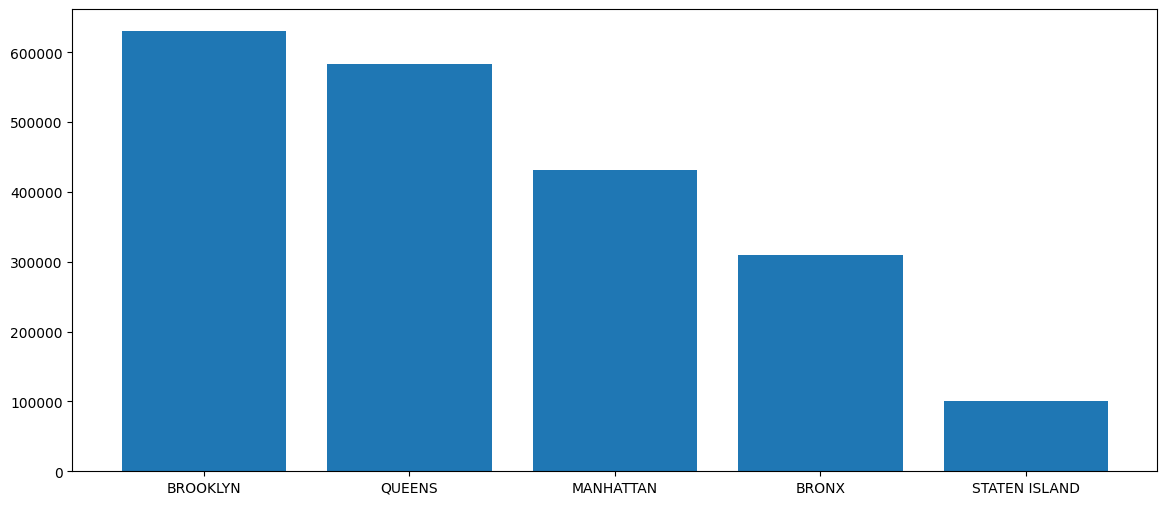

In [111]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(collisions_by_borough.index,collisions_by_borough.values)
plt.show()

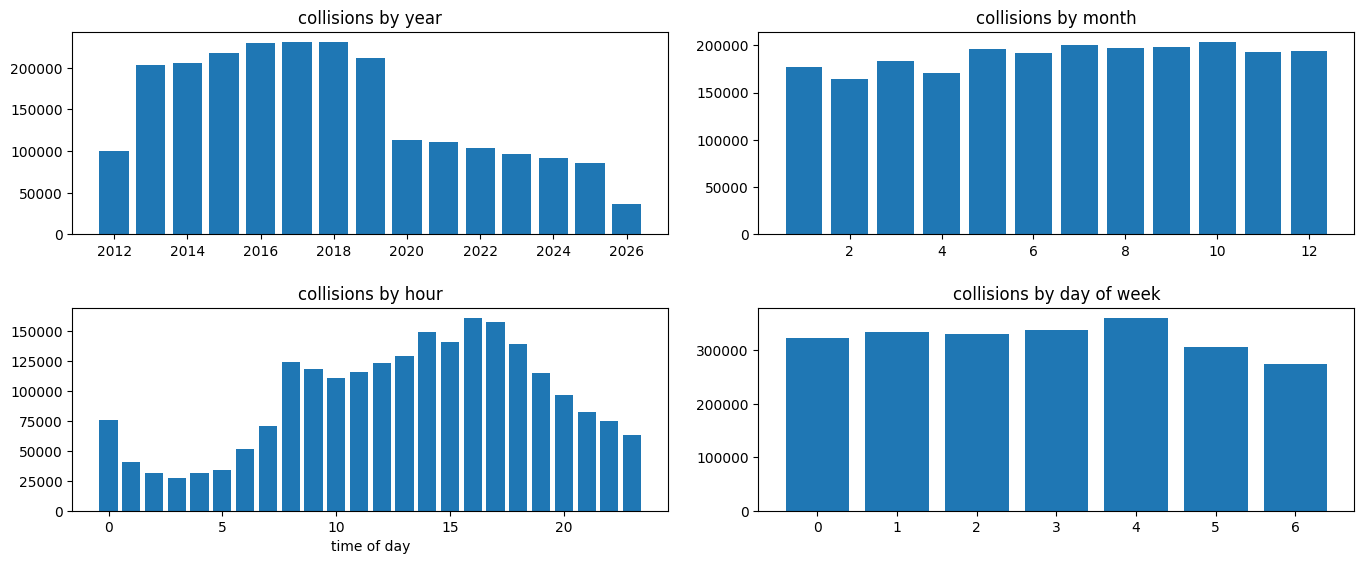

In [36]:
fig, axes = plt.subplots(2,2,figsize=(14, 6)) #figsize=(14, 6)
yearly_counts = df.groupby('YEAR')['YEAR'].count()
axes[0,0].bar(yearly_counts.index, yearly_counts.values)
axes[0,0].set_title('collisions by year')
monthly_counts = df.groupby('MONTH')['MONTH'].count()
axes[0,1].bar(monthly_counts.index, monthly_counts.values)
axes[0,1].set_title('collisions by month')
hourly_counts = df.groupby('HOUR')['HOUR'].count()
axes[1,0].bar(hourly_counts.index, hourly_counts.values)
axes[1,0].set_title('collisions by hour')
axes[1,0].set_xlabel('time of day')
day_of_week_counts = df.groupby('DAY_OF_WEEK')['DAY_OF_WEEK'].count()
axes[1,1].bar(day_of_week_counts.index, day_of_week_counts.values)
axes[1,1].set_title('collisions by day of week')
fig.tight_layout(pad=2.0)
plt.show()

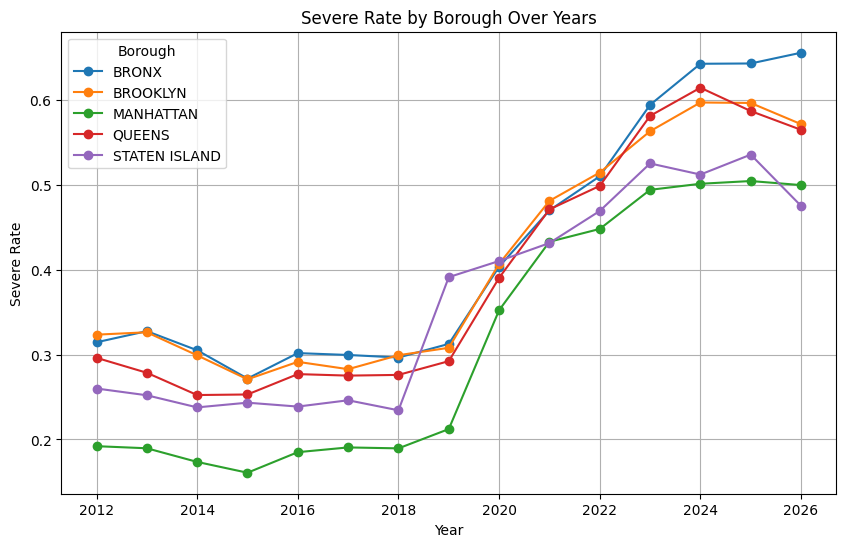

In [37]:
severe_rate_by_year.T.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Severe Rate by Borough Over Years')
plt.xlabel('Year')
plt.ylabel('Severe Rate')
plt.grid(True)
plt.legend(title='Borough')
plt.show()

In [38]:
len(df[(df['BOROUGH'].isna()) & (df['LATITUDE'].isna())])/len(df)*100

8.942894525660511

In [39]:
collision_location = df[['LATITUDE','LONGITUDE']].dropna()
collision_location = (collision_location[(collision_location['LATITUDE'] <= 40.9) 
                                        & (collision_location['LATITUDE'] >= 40.4) 
                                        & (collision_location['LONGITUDE'] >= -74.3)
                                        & (collision_location['LONGITUDE'] <= -73.6)]
)
collision_location.head()

,LATITUDE,LONGITUDE
2,40.621790,-73.970024
9,40.667202,-73.866500
10,40.683304,-73.917274
12,40.709183,-73.956825
13,40.868160,-73.831480


In [42]:
lons = collision_location['LONGITUDE'].to_list()
lats = collision_location['LATITUDE'].to_list()

In [8]:
#boroughs_gdf for nyc geospatial data

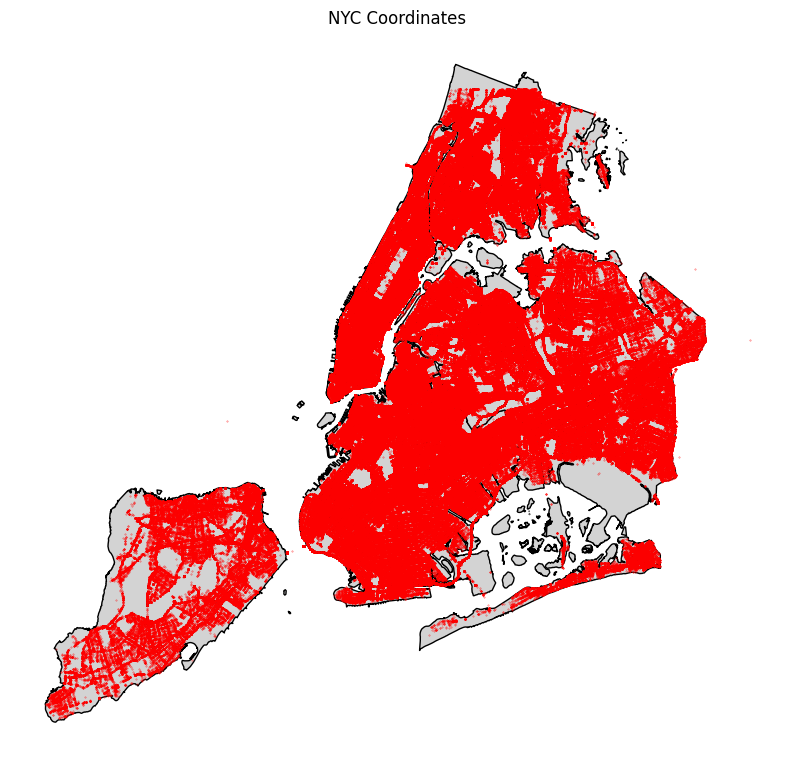

In [31]:
# fig, ax = plt.subplots(figsize=(10, 10))
# boroughs_gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

points_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lons, lats), 
    crs="EPSG:4326" # Standard WGS84 coordinate system
)

# 3. Plot them together
fig, ax = plt.subplots(figsize=(10, 10))

# Plot base map (polygon)
boroughs_gdf.plot(ax=ax, color='lightgrey', edgecolor='black')

# Plot points on top
points_gdf.plot(ax=ax, color='red', markersize=0.1, alpha=0.7)

# Format plot
plt.title('NYC Coordinates')
ax.set_axis_off() # Hides the axis grid
plt.show()

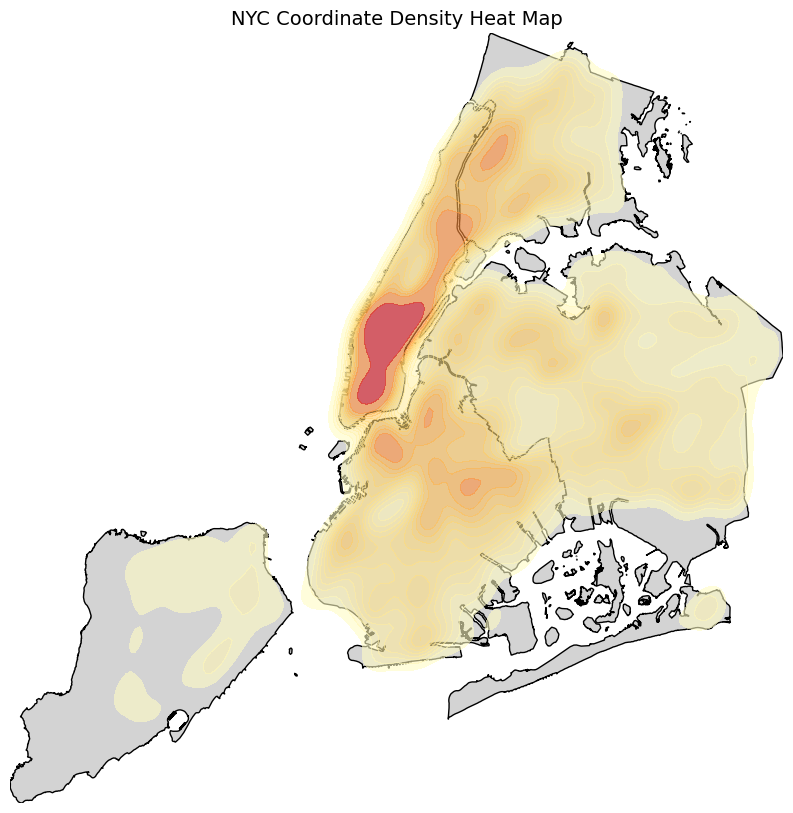

In [9]:
points_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lons, lats), 
    crs="EPSG:4326" # Standard WGS84 coordinate system
)

# 3. Plot them together
fig, ax = plt.subplots(figsize=(10, 10))
boroughs_gdf.plot(ax=ax, color='lightgrey', edgecolor='black')

sns.kdeplot(
    x=lons, 
    y=lats, 
    ax=ax,
    cmap='YlOrRd',  # Heatmap colormap (Yellow-Orange-Red)
    fill=True,      # Continuous shaded gradient
    thresh=0.05,    # Hides low-density noise outside the clusters
    alpha=0.6,      # Transparency so NYC background shows through
    levels=15       # Smoothness of the contour levels
)

# Format axes to match spatial boundaries
minx, miny, maxx, maxy = boroughs_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_axis_off()

plt.title('NYC Coordinate Density Heat Map', fontsize=14)
plt.show()

#### model training
now let's build for ourselves a useful prediction model. Assuming a location/date/time is known, what are the chances of that particular crash has high severity? (let's define severity as number of injured/death as of moment)

Transform cyclic time features (Hour, Month, Day of Week) into 2D coordinates on a clock face using sine and cosine transformations.

In [69]:
df['HOUR_SIN'] = np.sin(2 * np.pi * df['HOUR'] / 24.0)
df['HOUR_COS'] = np.cos(2 * np.pi * df['HOUR'] / 24.0)

df['MONTH_SIN'] = np.sin(2 * np.pi * df['MONTH'] / 12.0)
df['MONTH_COS'] = np.cos(2 * np.pi * df['MONTH'] / 12.0)

df['DAY_SIN'] = np.sin(2 * np.pi * df['DAY_OF_WEEK'] / 7.0)
df['DAY_COS'] = np.cos(2 * np.pi * df['DAY_OF_WEEK'] / 7.0)

In [67]:
input = (['HOUR_SIN','HOUR_COS','MONTH_SIN','MONTH_COS','DAY_SIN','DAY_COS',
        'LONGITUDE','LATITUDE','NUMBER OF PERSONS INJURED',
        'NUMBER OF PERSONS KILLED'])

In [72]:
trainingData = df[input]
trainingData.head()

,HOUR_SIN,HOUR_COS,MONTH_SIN,MONTH_COS,DAY_SIN,DAY_COS,LONGITUDE,LATITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED
0,0.500000,8.660254e-01,-1.000000e+00,-1.836970e-16,-0.974928,-0.222521,NaN,NaN,2.0,0.0
1,0.258819,-9.659258e-01,1.000000e+00,6.123234e-17,-0.974928,-0.222521,NaN,NaN,1.0,0.0
2,0.258819,9.659258e-01,-5.000000e-01,8.660254e-01,0.974928,-0.222521,-73.970024,40.62179,1.0,0.0
3,1.000000,6.123234e-17,1.224647e-16,-1.000000e+00,0.974928,-0.222521,NaN,NaN,0.0,0.0
4,-0.258819,-9.659258e-01,-1.000000e+00,-1.836970e-16,0.974928,-0.222521,NaN,NaN,0.0,0.0


clear nan and invalid locations

In [73]:
trainingData = trainingData.dropna()
trainingData = (trainingData[(trainingData['LATITUDE'] <= 40.9) 
                                        & (trainingData['LATITUDE'] >= 40.4) 
                                        & (trainingData['LONGITUDE'] >= -74.3)
                                        & (trainingData['LONGITUDE'] <= -73.6)]
)
trainingData

,HOUR_SIN,HOUR_COS,MONTH_SIN,MONTH_COS,DAY_SIN,DAY_COS,LONGITUDE,LATITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED
2,0.258819,9.659258e-01,-5.000000e-01,8.660254e-01,0.974928,-0.222521,-73.970024,40.621790,1.0,0.0
9,0.707107,-7.071068e-01,-1.000000e+00,-1.836970e-16,-0.974928,-0.222521,-73.866500,40.667202,0.0,0.0
10,0.866025,-5.000000e-01,-2.449294e-16,1.000000e+00,0.781831,0.623490,-73.917274,40.683304,0.0,0.0
12,-0.965926,-2.588190e-01,-2.449294e-16,1.000000e+00,0.781831,0.623490,-73.956825,40.709183,0.0,0.0
13,0.866025,-5.000000e-01,-2.449294e-16,1.000000e+00,0.781831,0.623490,-73.831480,40.868160,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2269182,0.500000,8.660254e-01,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-73.896430,40.860996,1.0,0.0
2269183,-0.965926,-2.588190e-01,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-73.979065,40.686710,0.0,0.0
2269184,-0.866025,-5.000000e-01,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-73.838990,40.861206,0.0,0.0
2269185,-1.000000,-1.836970e-16,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-73.902210,40.759950,0.0,0.0


In [77]:
# for col in ['NUMBER OF PERSONS INJURED','NUMBER OF PERSONS KILLED']:
#     series = trainingData[col]
#     q25, q75 = round(series.quantile(q=0.25),3), round(series.quantile(q=0.75),3)
#     IQR = round(q75-q25,3)
#     upper_bound = round(q75+1.5*IQR,3)
#     print(' '*5)
#     print(col,'q75 = ',q75, 'IQR = ', IQR)
#     print('upper: ',upper_bound)
#     print('num of outliers: ',(series > upper_bound).count())

     
NUMBER OF PERSONS INJURED q75 =  0.0 IQR =  0.0
upper:  0.0
num of outliers:  2015239
     
NUMBER OF PERSONS KILLED q75 =  0.0 IQR =  0.0
upper:  0.0
num of outliers:  2015239


In [79]:
trainingData['SEVERITY'] = (trainingData[['NUMBER OF PERSONS INJURED','NUMBER OF PERSONS KILLED']]
                           .sum(axis=1) > 0).astype(int)
trainingData

,HOUR_SIN,HOUR_COS,MONTH_SIN,MONTH_COS,DAY_SIN,DAY_COS,LONGITUDE,LATITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,SEVERITY
2,0.258819,9.659258e-01,-5.000000e-01,8.660254e-01,0.974928,-0.222521,-73.970024,40.621790,1.0,0.0,1
9,0.707107,-7.071068e-01,-1.000000e+00,-1.836970e-16,-0.974928,-0.222521,-73.866500,40.667202,0.0,0.0,0
10,0.866025,-5.000000e-01,-2.449294e-16,1.000000e+00,0.781831,0.623490,-73.917274,40.683304,0.0,0.0,0
12,-0.965926,-2.588190e-01,-2.449294e-16,1.000000e+00,0.781831,0.623490,-73.956825,40.709183,0.0,0.0,0
13,0.866025,-5.000000e-01,-2.449294e-16,1.000000e+00,0.781831,0.623490,-73.831480,40.868160,2.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
2269182,0.500000,8.660254e-01,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-73.896430,40.860996,1.0,0.0,1
2269183,-0.965926,-2.588190e-01,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-73.979065,40.686710,0.0,0.0,0
2269184,-0.866025,-5.000000e-01,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-73.838990,40.861206,0.0,0.0,0
2269185,-1.000000,-1.836970e-16,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-73.902210,40.759950,0.0,0.0,0


In [99]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

In [92]:
X = trainingData.drop(['SEVERITY','NUMBER OF PERSONS INJURED','NUMBER OF PERSONS KILLED'],axis=1)
y = trainingData['SEVERITY']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

# scale features before pca and knn
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# apply pca
# pca = PCA(n_components=2)
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_test_pca = pca.transform(X_test_scaled)

In [103]:
# n_jobs=-1 uses all cpu cores
model = LogisticRegression(class_weight='balanced', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
model.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_jobs=-1, weights='distance')

In [104]:
y_pred_knn = knn.predict(X_test_scaled)
y_pred_logistic = model.predict(X_test_scaled)

report for knn: 
               precision    recall  f1-score   support

           0       0.76      0.85      0.80    302322
           1       0.28      0.18      0.22    100726

    accuracy                           0.68    403048
   macro avg       0.52      0.51      0.51    403048
weighted avg       0.64      0.68      0.65    403048

report for logistic regression: 
               precision    recall  f1-score   support

           0       0.78      0.56      0.65    302322
           1       0.28      0.52      0.36    100726

    accuracy                           0.55    403048
   macro avg       0.53      0.54      0.51    403048
weighted avg       0.65      0.55      0.58    403048



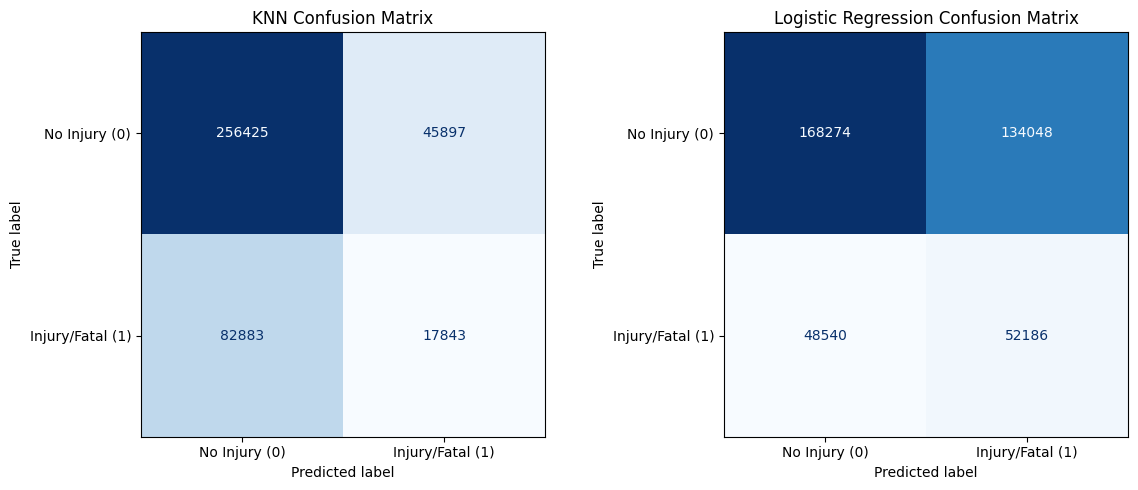

In [110]:
# print report
print('report for knn: \n',classification_report(y_test, y_pred_knn))
print('report for logistic regression: \n',classification_report(y_test, y_pred_logistic))

# confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn, display_labels=['No Injury (0)', 'Injury/Fatal (1)']
)
disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic, display_labels=['No Injury (0)', 'Injury/Fatal (1)']
)

# plot
fig, axes = plt.subplots(1,2,figsize=(12, 5))
disp_knn.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('KNN Confusion Matrix')
disp_logistic.plot(ax=axes[1], cmap='Blues', values_format='d', colorbar=False)
axes[1].set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

both models are equally bad (one with horrendous positive F1-score and one with slightly less horrendous F1-score but worse negative F1-score), but i guess that's it for demonstration process.